# MNIST MLP: TinyMML vs Keras

Explore handwritten digits, train equivalent multilayer perceptrons, and compare learning quality and CPU performance. The committed output uses the reduced profile; `full` and editable `custom` profiles use the same pipeline.

In [1]:
# Profile and CPU policy: keep this cell before numerical-library imports.
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
                 "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[variable] = "1"

PROFILE = os.environ.get("TINYMML_PROFILE", "reduced").lower()
CUSTOM_CONFIG = {
    "train_samples": 3_000, "test_samples": 500, "epochs": 5,
    "batch_size": 64, "inference_repeats": 5,
}
PROFILE_CONFIGS = {
    "reduced": {"train_samples": 3_000, "test_samples": 500, "epochs": 5,
                "batch_size": 64, "inference_repeats": 5},
    "full": {"train_samples": 60_000, "test_samples": 10_000, "epochs": 10,
             "batch_size": 128, "inference_repeats": 10},
    "custom": CUSTOM_CONFIG,
}

def resolve_config(profile):
    if profile not in PROFILE_CONFIGS:
        raise ValueError("TINYMML_PROFILE must be 'reduced', 'full', or 'custom'")
    config = dict(PROFILE_CONFIGS[profile])
    limits = {"train_samples": 60_000, "test_samples": 10_000}
    for key, maximum in limits.items():
        if not isinstance(config[key], int) or not 10 <= config[key] <= maximum:
            raise ValueError(f"{key} must be an integer between 10 and {maximum}")
    for key in ("epochs", "batch_size", "inference_repeats"):
        if not isinstance(config[key], int) or config[key] <= 0:
            raise ValueError(f"{key} must be a positive integer")
    return config

# Validate every profile definition without training the full/custom profiles.
for profile_name in PROFILE_CONFIGS:
    resolve_config(profile_name)
CONFIG = {**resolve_config(PROFILE), "seed": 42, "learning_rate": 1e-3}
CONFIG

{'train_samples': 3000,
 'test_samples': 500,
 'epochs': 5,
 'batch_size': 64,
 'inference_repeats': 5,
 'seed': 42,
 'learning_rate': 0.001}

In [2]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import platform
import sys

ROOT = Path.cwd()
if not (ROOT / "tinymodel").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from threadpoolctl import threadpool_limits

THREAD_LIMITER = threadpool_limits(limits=1)
import tensorflow as tf
import keras
tf.config.set_visible_devices([], "GPU")
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

import tinytensor as tt
import tinymodel as tm

np.random.seed(CONFIG["seed"])
tt.manual_seed(CONFIG["seed"])
keras.utils.set_random_seed(CONFIG["seed"])
assert tf.config.get_visible_devices("GPU") == []

def stratified_subset(labels, count, seed):
    indices = np.arange(len(labels))
    if count == len(labels):
        return indices
    selected, _ = train_test_split(indices, train_size=count, stratify=labels, random_state=seed)
    return np.asarray(selected)

def one_hot(labels, classes=10):
    return np.eye(classes, dtype=np.float32)[np.asarray(labels)]

def probabilities(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum(axis=1, keepdims=True)

def benchmark_inference(predict, samples, repeats):
    predict()
    durations = []
    for _ in range(repeats):
        started = perf_counter()
        predict()
        durations.append(perf_counter() - started)
    median = float(np.median(durations))
    return 1_000 * median, samples / median

def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(row[column]) for column in columns) + " |" for row in rows]
    return "\n".join([header, divider, *body])

environment = {
    "profile": PROFILE, "platform": platform.platform(), "machine": platform.machine(),
    "logical CPUs": os.cpu_count(), "Python": platform.python_version(),
    "NumPy": np.__version__, "TensorFlow": tf.__version__, "Keras": keras.__version__,
    "scikit-learn": version("scikit-learn"), "TinyTensor CUDA": tt.cuda_available(),
}
display(Markdown("## Environment and active profile\n" + "\n".join(f"- **{k}:** {v}" for k, v in environment.items())))
display(CONFIG)

## Environment and active profile
- **profile:** reduced
- **platform:** macOS-26.5.1-arm64-arm-64bit-Mach-O
- **machine:** arm64
- **logical CPUs:** 8
- **Python:** 3.13.14
- **NumPy:** 2.4.3
- **TensorFlow:** 2.21.0
- **Keras:** 3.15.0
- **scikit-learn:** 1.9.0
- **TinyTensor CUDA:** False

{'train_samples': 3000,
 'test_samples': 500,
 'epochs': 5,
 'batch_size': 64,
 'inference_repeats': 5,
 'seed': 42,
 'learning_rate': 0.001}

## Load and explore MNIST

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/11490434 ━━━━━━━━━━━━━━━━━━━━ 44s 4us/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 35s 3us/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 33s 3us/step

  147456/11490434 ━━━━━━━━━━━━━━━━━━━━ 23s 2us/step

...

 9568256/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

10551296/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11386880/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Official train/test: (60000, 28, 28) / (10000, 28, 28)
Selected train/test: (3000, 1, 28, 28) / (500, 1, 28, 28)
Pixel range after scaling: [0.0, 1.0]
Train class counts: [296, 337, 298, 307, 292, 271, 296, 313, 293, 297]


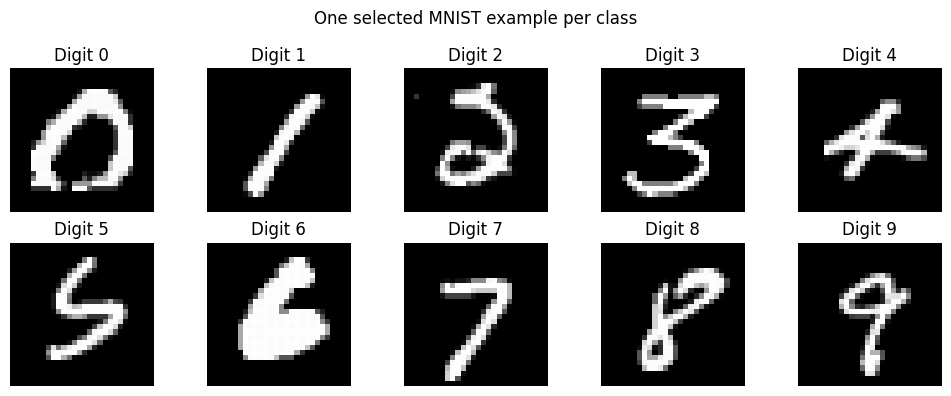

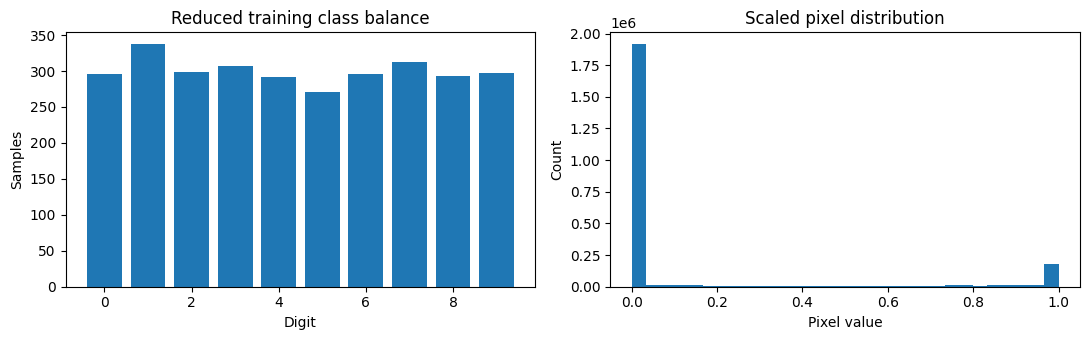

In [3]:
(x_train_all, y_train_all), (x_test_all, y_test_all) = keras.datasets.mnist.load_data()
train_indices = stratified_subset(y_train_all, CONFIG["train_samples"], CONFIG["seed"])
test_indices = stratified_subset(y_test_all, CONFIG["test_samples"], CONFIG["seed"] + 1)
x_train_images = x_train_all[train_indices].astype(np.float32) / 255.0
x_test_images = x_test_all[test_indices].astype(np.float32) / 255.0
y_train = y_train_all[train_indices]
y_test = y_test_all[test_indices]
x_train_tiny = np.ascontiguousarray(x_train_images[:, None, :, :])
x_test_tiny = np.ascontiguousarray(x_test_images[:, None, :, :])
x_train_keras = np.ascontiguousarray(x_train_images[:, :, :, None])
x_test_keras = np.ascontiguousarray(x_test_images[:, :, :, None])
y_train_one_hot, y_test_one_hot = one_hot(y_train), one_hot(y_test)

print(f"Official train/test: {x_train_all.shape} / {x_test_all.shape}")
print(f"Selected train/test: {x_train_tiny.shape} / {x_test_tiny.shape}")
print(f"Pixel range after scaling: [{x_train_images.min():.1f}, {x_train_images.max():.1f}]")
print("Train class counts:", np.bincount(y_train, minlength=10).tolist())

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, axis in enumerate(axes.flat):
    image_index = np.flatnonzero(y_train == digit)[0]
    axis.imshow(x_train_images[image_index], cmap="gray")
    axis.set_title(f"Digit {digit}")
    axis.axis("off")
plt.suptitle("One selected MNIST example per class")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(np.arange(10), np.bincount(y_train, minlength=10))
axes[0].set(title="Reduced training class balance", xlabel="Digit", ylabel="Samples")
axes[1].hist(x_train_images.ravel(), bins=30)
axes[1].set(title="Scaled pixel distribution", xlabel="Pixel value", ylabel="Count")
plt.tight_layout()
plt.show()

## Matched MLPs

Both models use `Flatten → 128 → ReLU → Dropout(0.2) → 64 → ReLU → Dropout(0.2) → 10`, He initialization, Adam at `1e-3`, and logits categorical cross-entropy.

In [4]:
tt.manual_seed(CONFIG["seed"])
tiny_model = tm.Model([
    tm.Flatten(), tm.Linear(128, init="he"), tm.ReLU(), tm.Dropout(0.2),
    tm.Linear(64, init="he"), tm.ReLU(), tm.Dropout(0.2), tm.Linear(10),
])
tiny_model.build(list(x_train_tiny.shape))
tiny_optimizer = tm.Adam(tiny_model.parameters(), lr=CONFIG["learning_rate"])
tiny_loss = tm.CrossEntropyLoss()

keras.utils.set_random_seed(CONFIG["seed"])
keras_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)), keras.layers.Flatten(),
    keras.layers.Dense(128, kernel_initializer="he_normal"), keras.layers.ReLU(), keras.layers.Dropout(0.2),
    keras.layers.Dense(64, kernel_initializer="he_normal"), keras.layers.ReLU(), keras.layers.Dropout(0.2),
    keras.layers.Dense(10),
])
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"]),
    loss=keras.losses.CategoricalCrossentropy(from_logits=True), metrics=["accuracy"],
)

model_info = [
    {"library": "TinyMML", "parameters": sum(p.size() for p in tiny_model.parameters()),
     "input layout": "NCHW", "steps/epoch": int(np.ceil(len(x_train_tiny) / CONFIG["batch_size"]))},
    {"library": "Keras", "parameters": keras_model.count_params(),
     "input layout": "NHWC", "steps/epoch": int(np.ceil(len(x_train_keras) / CONFIG["batch_size"]))},
]
display(Markdown(markdown_table(model_info, ["library", "parameters", "input layout", "steps/epoch"])))

| library | parameters | input layout | steps/epoch |
| --- | --- | --- | --- |
| TinyMML | 109386 | NCHW | 47 |
| Keras | 109386 | NHWC | 47 |

In [5]:
np.random.seed(CONFIG["seed"])
tt.manual_seed(CONFIG["seed"])
started = perf_counter()
tiny_history = tiny_model.fit(
    x_train_tiny, y_train_one_hot, epochs=CONFIG["epochs"], batch_size=CONFIG["batch_size"],
    optimizer=tiny_optimizer, loss_fn=tiny_loss, metric="accuracy", verbose=False,
)
tiny_train_seconds = perf_counter() - started

keras.utils.set_random_seed(CONFIG["seed"])
started = perf_counter()
keras_history = keras_model.fit(
    x_train_keras, y_train_one_hot, epochs=CONFIG["epochs"], batch_size=CONFIG["batch_size"],
    shuffle=True, verbose=0,
)
keras_train_seconds = perf_counter() - started

tiny_test_loss, tiny_test_accuracy, tiny_logits = tiny_model.evaluate(
    x_test_tiny, y_test_one_hot, tiny_loss, batch_size=CONFIG["batch_size"],
    metric="accuracy", return_outputs=True,
)
keras_evaluation = keras_model.evaluate(x_test_keras, y_test_one_hot, batch_size=CONFIG["batch_size"], verbose=0, return_dict=True)
keras_logits = keras_model.predict(x_test_keras, batch_size=CONFIG["batch_size"], verbose=0)
tiny_probabilities, keras_probabilities = probabilities(tiny_logits), probabilities(keras_logits)
tiny_predictions, keras_predictions = tiny_probabilities.argmax(1), keras_probabilities.argmax(1)
tiny_latency, tiny_throughput = benchmark_inference(
    lambda: tiny_model.predict(x_test_tiny, batch_size=CONFIG["batch_size"]), len(x_test_tiny), CONFIG["inference_repeats"],
)
keras_latency, keras_throughput = benchmark_inference(
    lambda: keras_model.predict(x_test_keras, batch_size=CONFIG["batch_size"], verbose=0), len(x_test_keras), CONFIG["inference_repeats"],
)

results = [
    {"library": "TinyMML", "test loss": f"{tiny_test_loss:.4f}", "accuracy": f"{tiny_test_accuracy:.3f}",
     "macro F1": f"{f1_score(y_test, tiny_predictions, average='macro'):.3f}", "training s": f"{tiny_train_seconds:.2f}",
     "inference ms": f"{tiny_latency:.2f}", "samples/s": f"{tiny_throughput:.1f}"},
    {"library": "Keras", "test loss": f"{keras_evaluation['loss']:.4f}", "accuracy": f"{accuracy_score(y_test, keras_predictions):.3f}",
     "macro F1": f"{f1_score(y_test, keras_predictions, average='macro'):.3f}", "training s": f"{keras_train_seconds:.2f}",
     "inference ms": f"{keras_latency:.2f}", "samples/s": f"{keras_throughput:.1f}"},
]
display(Markdown("## Reduced-profile results\n" + markdown_table(results, list(results[0]))))

## Reduced-profile results
| library | test loss | accuracy | macro F1 | training s | inference ms | samples/s |
| --- | --- | --- | --- | --- | --- | --- |
| TinyMML | 0.3085 | 0.912 | 0.911 | 5.45 | 86.87 | 5755.5 |
| Keras | 0.3190 | 0.904 | 0.903 | 1.20 | 35.32 | 14157.5 |

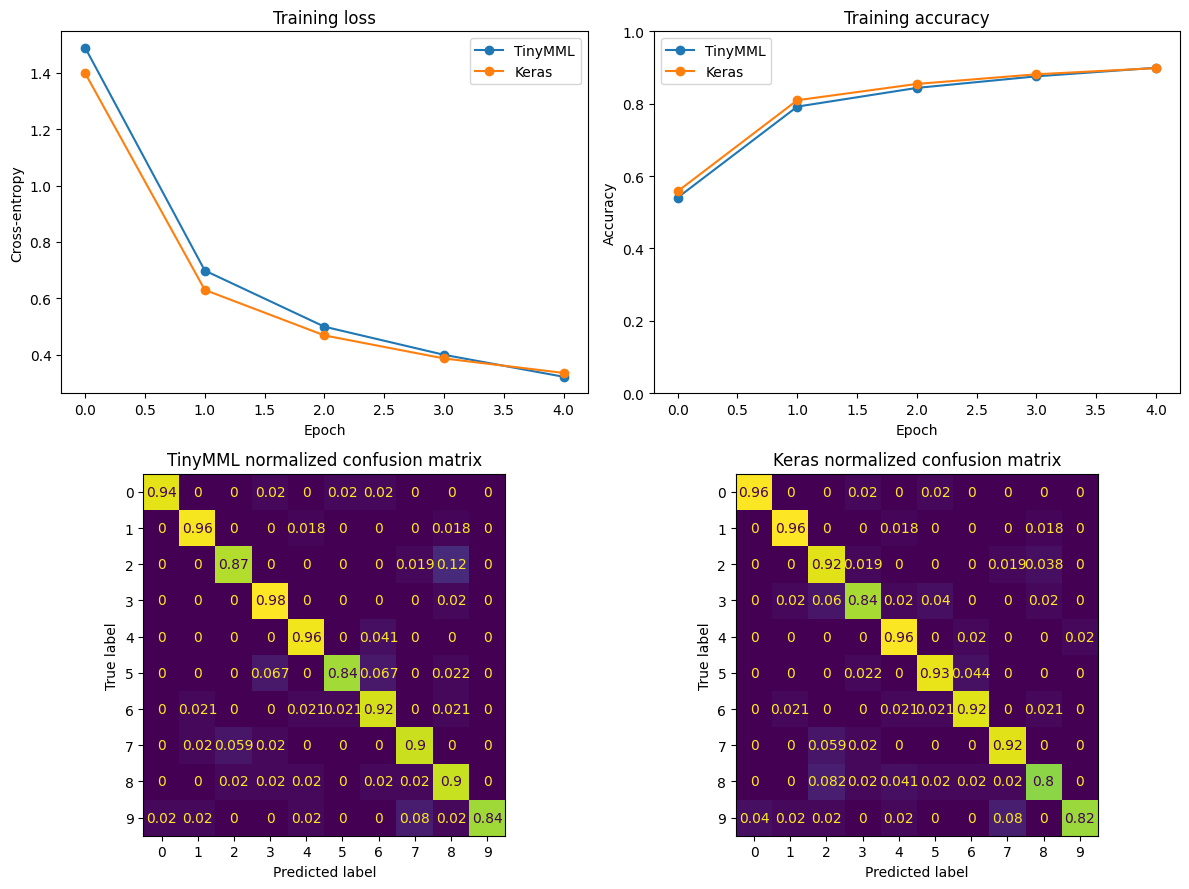

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].plot(tiny_history["loss"], marker="o", label="TinyMML")
axes[0, 0].plot(keras_history.history["loss"], marker="o", label="Keras")
axes[0, 0].set(title="Training loss", xlabel="Epoch", ylabel="Cross-entropy")
axes[0, 0].legend()
axes[0, 1].plot(tiny_history["metric"], marker="o", label="TinyMML")
axes[0, 1].plot(keras_history.history["accuracy"], marker="o", label="Keras")
axes[0, 1].set(title="Training accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
axes[0, 1].legend()
ConfusionMatrixDisplay.from_predictions(y_test, tiny_predictions, normalize="true", ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("TinyMML normalized confusion matrix")
ConfusionMatrixDisplay.from_predictions(y_test, keras_predictions, normalize="true", ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("Keras normalized confusion matrix")
plt.tight_layout()
plt.show()

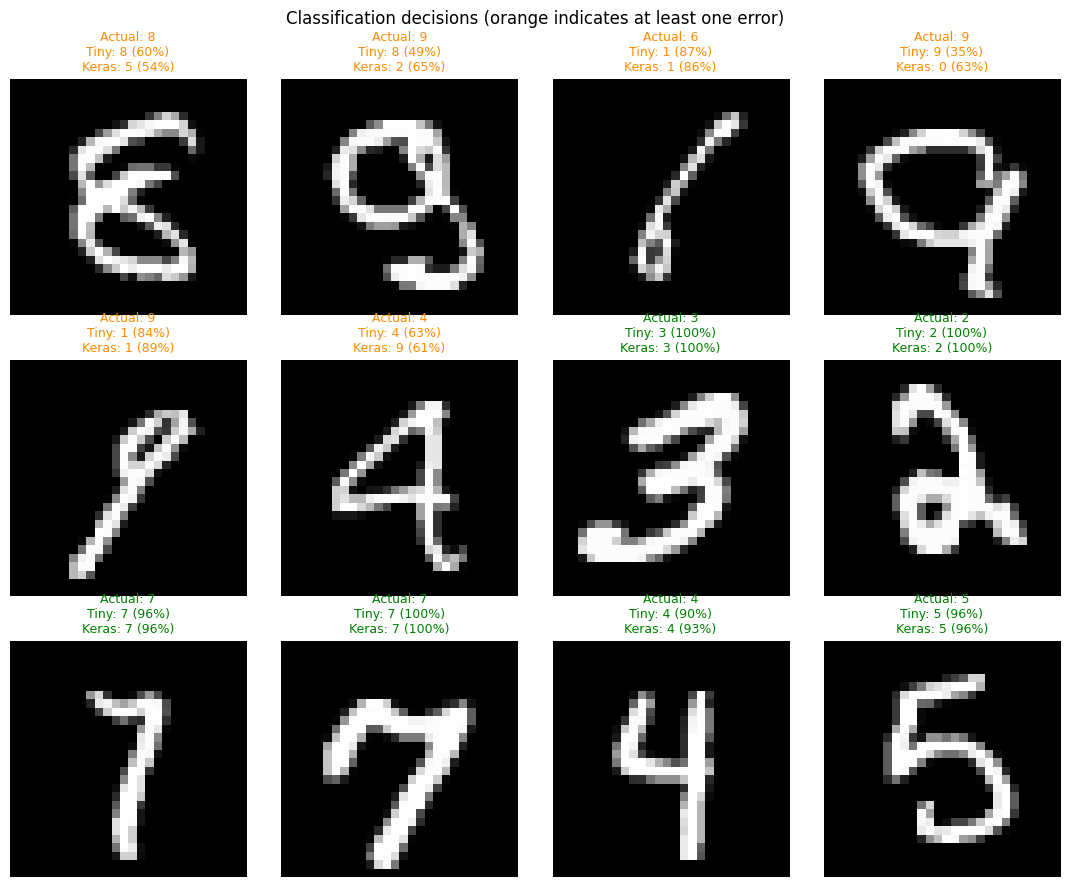

MNIST NOTEBOOK ACCEPTANCE PASSED


In [7]:
wrong = np.flatnonzero((tiny_predictions != y_test) | (keras_predictions != y_test))[:6]
correct = np.flatnonzero((tiny_predictions == y_test) & (keras_predictions == y_test))[:12 - len(wrong)]
decision_indices = np.concatenate([wrong, correct])[:12]
fig, axes = plt.subplots(3, 4, figsize=(11, 9))
for axis, index in zip(axes.flat, decision_indices):
    axis.imshow(x_test_images[index], cmap="gray")
    actual = y_test[index]
    title_color = "green" if tiny_predictions[index] == actual and keras_predictions[index] == actual else "darkorange"
    axis.set_title(
        f"Actual: {actual}\nTiny: {tiny_predictions[index]} ({tiny_probabilities[index].max():.0%})"
        f"\nKeras: {keras_predictions[index]} ({keras_probabilities[index].max():.0%})",
        color=title_color, fontsize=9,
    )
    axis.axis("off")
for axis in axes.flat[len(decision_indices):]:
    axis.axis("off")
plt.suptitle("Classification decisions (orange indicates at least one error)")
plt.tight_layout()
plt.show()

assert np.isfinite(tiny_history["loss"]).all() and np.isfinite(keras_history.history["loss"]).all()
assert tiny_history["loss"][-1] < tiny_history["loss"][0]
assert keras_history.history["loss"][-1] < keras_history.history["loss"][0]
assert tiny_test_accuracy > 0.80, f"TinyMML MNIST accuracy too low: {tiny_test_accuracy:.3f}"
assert accuracy_score(y_test, keras_predictions) > 0.80
assert np.isfinite(tiny_probabilities).all() and np.isfinite(keras_probabilities).all()
np.testing.assert_allclose(tiny_probabilities.sum(1), 1.0, atol=1e-5)
np.testing.assert_allclose(keras_probabilities.sum(1), 1.0, atol=1e-5)
print("MNIST NOTEBOOK ACCEPTANCE PASSED")